<a href="https://colab.research.google.com/github/Aadi2612/urban-rural-erosion-prediction/blob/main/notebooks/Rural_ml_code.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Rural Model ML Prediction


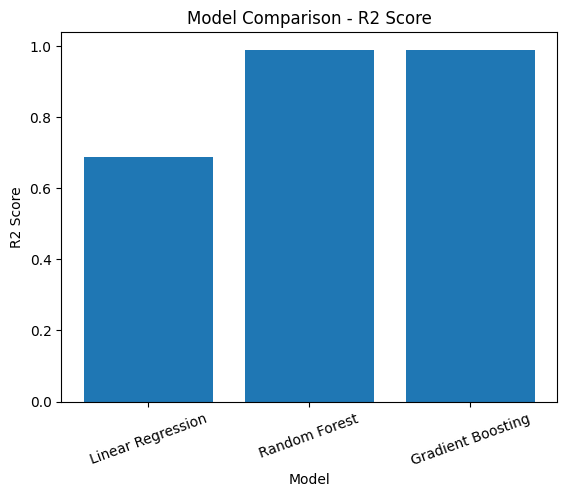

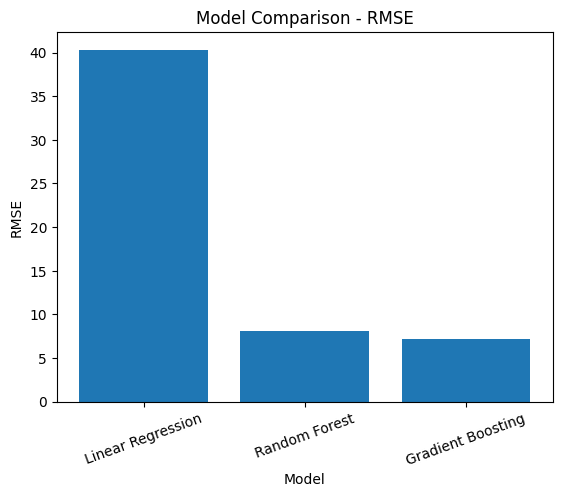

Best Model Selected: Gradient Boosting


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("thanjavur_ml.csv")

df.head()

features = [
    "thanjavur_dem_250",
    "rainfall_250m",
    "thanjavur_kfactor_250m",
    "soil_moisture_250m",
    "thanjavur_ndvi_250m",
    "sand_thanjavur_250m",
    "clay_thanjavur_250m",
    "lulc_250m",
    "slope_250m"
]

X = df[features]
y = df["soil_loss_thanjavur"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    results.append([name, r2, rmse])

results_df = pd.DataFrame(results, columns=["Model", "R2 Score", "RMSE"])
results_df

plt.figure()
plt.bar(results_df["Model"], results_df["R2 Score"])
plt.xlabel("Model")
plt.ylabel("R2 Score")
plt.title("Model Comparison - R2 Score")
plt.xticks(rotation=20)
plt.show()

plt.figure()
plt.bar(results_df["Model"], results_df["RMSE"])
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.title("Model Comparison - RMSE")
plt.xticks(rotation=20)
plt.show()

best_model_name = results_df.sort_values("R2 Score", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model Selected:", best_model_name)

best_model.fit(X, y)

df["soil_loss_pred"] = best_model.predict(X)

output = df[["fid", "soil_loss_pred"]]

output.to_csv("thanjavur_predictions.csv", index=False)